In [1]:
from google.colab import drive, files
from pathlib import Path
import zipfile

drive.mount("/content/drive")

# Keep the leading space before AI: it matches your Drive folder.
artifact_dir = Path(
    "/content/drive/MyDrive/ AI-Engineering-Journey/"
    "artifacts/patchcore-bottle"
)

export_files = {
    "random_memory_comparison.csv":
        "results/random_memory_comparison.csv",

    "random_memory_comparison_scores.csv":
        "results/random_memory_comparison_scores.csv",

    "figures/random_memory_tradeoff.png":
        "figures/random_memory_tradeoff.png",

    "figures/ranking_vs_threshold_seed44_0p5pct.png":
        "figures/ranking_vs_threshold_seed44_0p5pct.png",
}

missing = [
    source
    for source in export_files
    if not (artifact_dir / source).is_file()
]

if missing:
    raise FileNotFoundError(
        "These files were not found:\n" + "\n".join(missing)
    )

zip_path = Path("/content/patchcore_results_export.zip")

with zipfile.ZipFile(
    zip_path, mode="w", compression=zipfile.ZIP_DEFLATED
) as archive:
    for source, destination in export_files.items():
        archive.write(
            artifact_dir / source,
            arcname=destination,
        )
        print("Added:", destination)

print(f"\nDownload size: {zip_path.stat().st_size / 1024:.1f} KiB")
files.download(str(zip_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Added: results/random_memory_comparison.csv
Added: results/random_memory_comparison_scores.csv
Added: figures/random_memory_tradeoff.png
Added: figures/ranking_vs_threshold_seed44_0p5pct.png

Download size: 249.0 KiB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from pathlib import Path

my_drive = Path("/content/drive/MyDrive")
project = my_drive / "AI-Engineering-Journey"
datasets = project / "datasets"

for folder in [my_drive, project, datasets]:
    print(f"\nChecking: {folder}")

    if not folder.is_dir():
        print("FOLDER NOT FOUND")
        break

    for item in sorted(folder.iterdir()):
        print(repr(item.name), "— folder" if item.is_dir() else "— file")


Checking: /content/drive/MyDrive
' AI-Engineering-Journey' — folder
'AP2_ Fachinformatik_Daten_Prozess_Analyse' — folder
'Abschlusspr.rar.adding' — file
'AnmeldungTeams_Kurzform_inkl. Passwort.pdf' — file
'B612_20200305_172726_450.jpg' — file
'Boarding-Pass-Duesseldorf-Paris-3371664472.pdf' — file
'Boarding-Pass-Paris-Amsterdam-3371676168.pdf' — file
'Booking.com_ Confirmation.pdf' — file
'Brochure.gdoc' — file
'C1 email-beschwerde1.gdoc' — file
'Concept note Celebration of WMHD.docx' — file
'Document from Khadija☘️ (1).pdf' — file
'Document from Khadija☘️ (2).pdf' — file
'Document from Khadija☘️.pdf' — file
'EN_3_ViDia Lungenkrebszentrum.pdf' — file
'EPK 3.drawio' — file
'Einladung Elterncafé 03.06.26.gdoc' — file
'Einladung Elterncafé 03.06.26.pdf' — file
'ExcelDashboard_DigitalSales_KRezapoor.xlsx' — file
'Forumbeitreg über die Thema (1).gdoc' — file
'Forumbeitreg über die Thema.gdoc' — file
'Frima.drawio' — file
'Gmail - Fwd_ Antrag auf Verlängerung der Aufenthaltserlaubnis f

In [4]:
from google.colab import drive
from pathlib import Path
import shutil
import zipfile

# 1. Connect Google Drive.
drive.mount("/content/drive")

# The space before AI matches the path we found in your Drive.
archive_source = Path(
    "/content/drive/MyDrive/ AI-Engineering-Journey/datasets/bottle.zip"
)
extract_dir = Path("/content/patchcore_bottle_data")


def find_dataset_roots():
    return [
        folder.parent
        for folder in extract_dir.rglob("train")
        if folder.is_dir()
        and (folder / "good").is_dir()
        and (folder.parent / "test").is_dir()
        and (folder.parent / "ground_truth").is_dir()
    ]


# 2. Reuse the extracted dataset if it already exists.
roots = find_dataset_roots()

if not roots:
    if not archive_source.is_file():
        raise FileNotFoundError(f"Cannot find archive: {archive_source}")

    local_archive = Path("/content/patchcore_source.zip")

    print("Copying ZIP from Drive...")
    shutil.copy2(archive_source, local_archive)

    print("Extracting ZIP...")
    extract_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(local_archive) as archive:
        archive.extractall(extract_dir)

    roots = find_dataset_roots()

# 3. Set the variable used by the image-display cell.
if len(roots) != 1:
    print("Extracted folder sample:")
    for path in list(extract_dir.rglob("*"))[:30]:
        print(path.relative_to(extract_dir))

    raise RuntimeError(
        f"Expected one dataset root, found {len(roots)}. "
        "Send me the folder sample printed above."
    )

DATA_ROOT = roots[0]

print("\nDataset ready:", DATA_ROOT)
print("Normal training images:", len(list((DATA_ROOT / "train/good").glob("*.png"))))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copying ZIP from Drive...
Extracting ZIP...

Dataset ready: /content/patchcore_bottle_data/bottle/bottle
Normal training images: 209


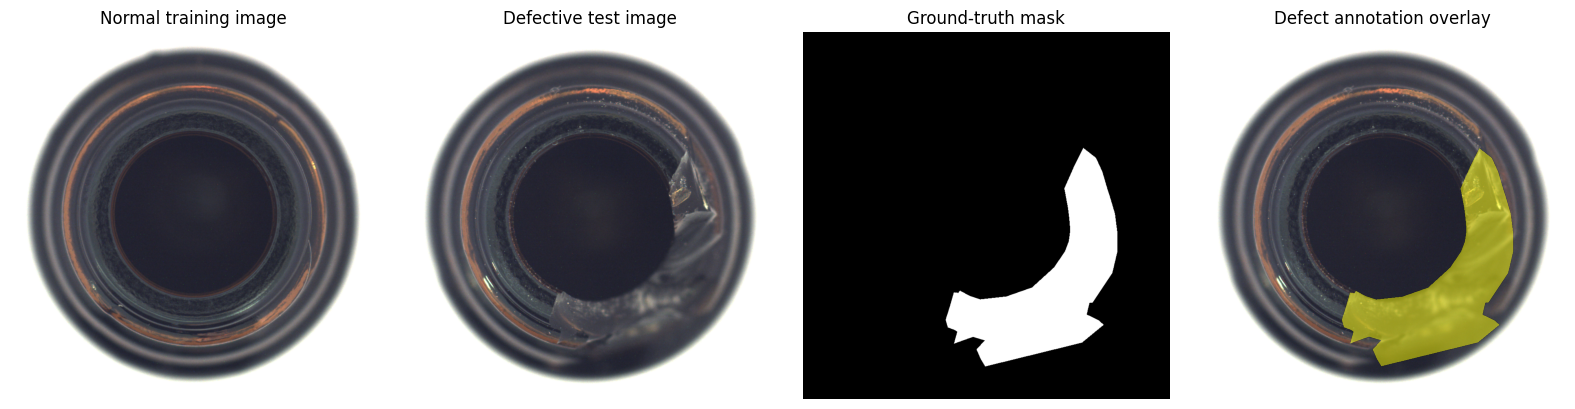

Image shape: (900, 900, 3)
Mask values: [  0 255]


In [5]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Select one normal image and one defective image.
normal_path = sorted((DATA_ROOT / "train/good").glob("*.png"))[0]
defect_path = sorted((DATA_ROOT / "test/broken_large").glob("*.png"))[0]

# Match the annotation to the defective image by filename.
mask_path = (
    DATA_ROOT
    / "ground_truth"
    / defect_path.parent.name
    / f"{defect_path.stem}_mask.png"
)

normal = np.array(Image.open(normal_path).convert("RGB"))
defect = np.array(Image.open(defect_path).convert("RGB"))
mask = np.array(Image.open(mask_path).convert("L"))

assert defect.shape[:2] == mask.shape, "Image and mask sizes differ"

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(normal)
axes[0].set_title("Normal training image")

axes[1].imshow(defect)
axes[1].set_title("Defective test image")

axes[2].imshow(mask, cmap="gray")
axes[2].set_title("Ground-truth mask")

axes[3].imshow(defect)
axes[3].imshow(
    np.ma.masked_where(mask == 0, mask),
    cmap="autumn",
    alpha=0.5,
    vmin=0,
    vmax=255,
)
axes[3].set_title("Defect annotation overlay")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

print("Image shape:", defect.shape)
print("Mask values:", np.unique(mask))

In [6]:
import torch
import torchvision
from torchvision.models import wide_resnet50_2, Wide_ResNet50_2_Weights
from torchvision.models.feature_extraction import create_feature_extractor
from PIL import Image

if "DATA_ROOT" not in globals():
    raise RuntimeError("Run the dataset setup cell first.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

# Explicitly select the pretrained ImageNet weights.
weights = Wide_ResNet50_2_Weights.IMAGENET1K_V1
backbone = wide_resnet50_2(weights=weights)

# Return intermediate features instead of classification predictions.
extractor = create_feature_extractor(
    backbone,
    return_nodes={
        "layer2": "layer2",
        "layer3": "layer3",
    },
).to(device)

extractor.eval()
extractor.requires_grad_(False)

# Resize, crop to 224 × 224, and normalize for these weights.
preprocess = weights.transforms()

image_path = sorted((DATA_ROOT / "train/good").glob("*.png"))[0]

with Image.open(image_path) as image:
    image_tensor = preprocess(image.convert("RGB"))

# Add a batch dimension: one image becomes a batch of one.
image_batch = image_tensor.unsqueeze(0).to(device)

with torch.inference_mode():
    features = extractor(image_batch)

print("\nInput:", tuple(image_batch.shape))
for name, tensor in features.items():
    print(f"{name}: {tuple(tensor.shape)}")

Device: cuda
PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
Downloading: "https://download.pytorch.org/models/wide_resnet50_2-95faca4d.pth" to /root/.cache/torch/hub/checkpoints/wide_resnet50_2-95faca4d.pth


100%|██████████| 132M/132M [00:00<00:00, 165MB/s]



Input: (1, 3, 224, 224)
layer2: (1, 512, 28, 28)
layer3: (1, 1024, 14, 14)


| Output | Interpretation |
|---|---|
| `layer2` | A 28×28 grid with 512 feature values at each position |
| `layer3` | A coarser 14×14 grid with 1,024 feature values at each position |

The steps are:
1. Collect a 3×3 neighborhood around each feature-grid position.
2. Align the coarser layer3 grid with the layer2 grid.
3. Pool each layer’s patch description to 1,024 values.
4. Combine the two descriptions and pool to a final 1,024-value vector.

In [7]:
import torch
import torch.nn.functional as F


@torch.inference_mode()
def make_patch_embeddings(features, embedding_dim=1024):
    """Convert layer2 and layer3 features into aligned patch vectors."""
    reference_size = features["layer2"].shape[-2:]
    layer_embeddings = []

    for name in ["layer2", "layer3"]:
        feature_map = features[name]
        batch, channels, height, width = feature_map.shape

        # Gather overlapping 3×3 neighborhoods.
        # Shape: [batch, channels * 9, height * width]
        patches = F.unfold(
            feature_map,
            kernel_size=3,
            stride=1,
            padding=1,
        )

        # Restore the spatial grid while keeping patch contents as channels.
        patches = patches.reshape(
            batch, channels * 9, height, width
        )

        # Align layer3's 14×14 grid with layer2's 28×28 grid.
        if (height, width) != reference_size:
            patches = F.interpolate(
                patches,
                size=reference_size,
                mode="bilinear",
                align_corners=False,
            )

        # One row per spatial position, across all images in the batch.
        patches = patches.permute(0, 2, 3, 1).reshape(
            -1, channels * 9
        )

        # Match the reference implementation's MeanMapper.
        pooled = F.adaptive_avg_pool1d(
            patches.unsqueeze(1),
            embedding_dim,
        ).squeeze(1)

        layer_embeddings.append(pooled)

    # Combine both layers, then match the reference Aggregator.
    combined = torch.stack(layer_embeddings, dim=1)

    embeddings = F.adaptive_avg_pool1d(
        combined.reshape(combined.shape[0], 1, -1),
        embedding_dim,
    ).squeeze(1)

    return embeddings


patch_embeddings = make_patch_embeddings(features)

assert patch_embeddings.shape == (784, 1024)
assert torch.isfinite(patch_embeddings).all()

print("Patch embeddings:", tuple(patch_embeddings.shape))
print(
    "Storage for this image:",
    f"{patch_embeddings.numel() * patch_embeddings.element_size() / 1024**2:.2f} MiB",
)

Patch embeddings: (784, 1024)
Storage for this image: 3.06 MiB


The reference grid has 28 × 28 = 784 positions. Each row describes one position and its surrounding visual context.
These vectors are still features, not anomaly scores. Once we collect normal training-image vectors into a memory bank, we can measure how far a new patch is from its nearest normal example.

In [8]:
# to define the split
import random

normal_paths = sorted((DATA_ROOT / "train/good").glob("*.png"))

# A fixed seed makes the split repeatable.
shuffled_paths = normal_paths.copy()
random.Random(42).shuffle(shuffled_paths)

n_validation = len(shuffled_paths) // 5

validation_paths = sorted(shuffled_paths[:n_validation])
training_paths = sorted(shuffled_paths[n_validation:])

assert set(training_paths).isdisjoint(validation_paths)

print("Training images:", len(training_paths))
print("Validation images:", len(validation_paths))

Training images: 168
Validation images: 41


## cell to extract and store the training embeddings

In [9]:
from tqdm.auto import tqdm

extractor.eval()
embedding_batches = []

with torch.inference_mode():
    for path in tqdm(training_paths, desc="Building normal memory"):
        with Image.open(path) as image:
            batch = preprocess(
                image.convert("RGB")
            ).unsqueeze(0).to(device)

        image_features = extractor(batch)
        embeddings = make_patch_embeddings(image_features)

        embedding_batches.append(embeddings.cpu())

memory_bank = torch.cat(embedding_batches, dim=0)
del embedding_batches

assert memory_bank.shape == (len(training_paths) * 784, 1024)
assert torch.isfinite(memory_bank).all()

print("Memory bank shape:", tuple(memory_bank.shape))
print(
    "Memory bank size:",
    f"{memory_bank.numel() * memory_bank.element_size() / 1024**2:.1f} MiB",
)

Building normal memory:   0%|          | 0/168 [00:00<?, ?it/s]

Memory bank shape: (131712, 1024)
Memory bank size: 514.5 MiB


Drive so you don’t need to repeat extraction next session

In [10]:
import json

artifact_dir = archive_source.parent.parent / "artifacts" / "patchcore-bottle"
artifact_dir.mkdir(parents=True, exist_ok=True)

torch.save(memory_bank, artifact_dir / "full_memory_bank.pt")

metadata = {
    "seed": 42,
    "training_images": [
        str(path.relative_to(DATA_ROOT)) for path in training_paths
    ],
    "validation_images": [
        str(path.relative_to(DATA_ROOT)) for path in validation_paths
    ],
    "backbone": "wide_resnet50_2",
    "weights": "IMAGENET1K_V1",
    "preprocessing": str(preprocess),
    "layers": ["layer2", "layer3"],
    "patch_size": 3,
    "embedding_dim": 1024,
    "torch_version": torch.__version__,
    "torchvision_version": torchvision.__version__,
}

with open(artifact_dir / "metadata.json", "w") as file:
    json.dump(metadata, file, indent=2)

print("Saved to:", artifact_dir)

Saved to: /content/drive/MyDrive/ AI-Engineering-Journey/artifacts/patchcore-bottle


to establish a random-sampling baseline. Later, we’ll compare it with PatchCore’s representative coreset selection to measure whether that more sophisticated selection helps.

In [11]:
import torch

# Keep 1% of the full bank, with repeatable random sampling.
sampling_ratio = 0.01
sample_count = max(1, int(len(memory_bank) * sampling_ratio))

generator = torch.Generator().manual_seed(42)
sample_indices = torch.randperm(
    len(memory_bank),
    generator=generator,
)[:sample_count]

sampled_memory_bank = memory_bank[sample_indices].contiguous()

print("Full bank:", tuple(memory_bank.shape))
print("Sampled bank:", tuple(sampled_memory_bank.shape))
print(
    "Sampled storage:",
    f"{sampled_memory_bank.numel() * sampled_memory_bank.element_size() / 1024**2:.2f} MiB",
)

# Preserve exactly which vectors were selected.
torch.save(
    {
        "indices": sample_indices,
        "sampling_ratio": sampling_ratio,
        "seed": 42,
    },
    artifact_dir / "random_sample_1pct.pt",
)

Full bank: (131712, 1024)
Sampled bank: (1317, 1024)
Sampled storage: 5.14 MiB


andom sampling may discard useful examples of normal appearance, causing false alarms. Next, we’ll score a held-out normal image against this smaller bank and inspect its distance map.

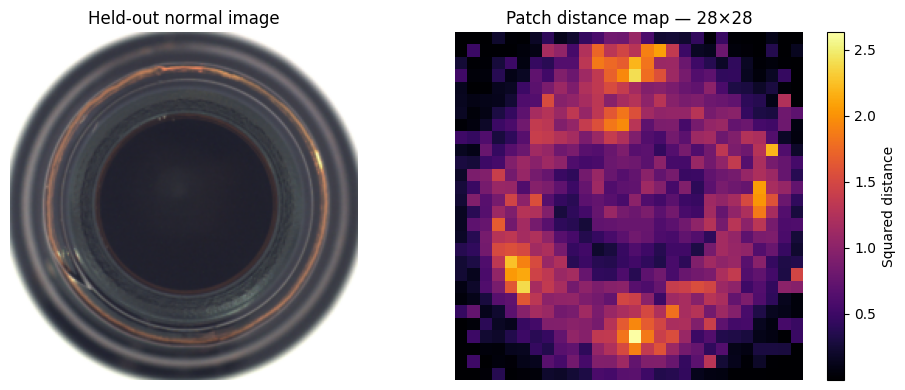

Image: 002.png
Patch scores: (784,)
Image anomaly score: 2.6303


In [12]:
import torch
import matplotlib.pyplot as plt
from PIL import Image

# Use a validation image that was excluded from the memory bank.
query_path = validation_paths[0]
assert query_path not in training_paths

with Image.open(query_path) as image:
    query_tensor = preprocess(image.convert("RGB"))

# Match the reference implementation's squared Euclidean distance.
with torch.inference_mode():
    query_features = extractor(query_tensor.unsqueeze(0).to(device))
    query_embeddings = make_patch_embeddings(query_features)

    reference_bank = sampled_memory_bank.to(device)

    # Compare in chunks to keep working memory manageable.
    patch_score_chunks = []

    for chunk in query_embeddings.split(128):
        distances = torch.cdist(chunk, reference_bank, p=2)
        nearest_squared_distances = distances.min(dim=1).values.square()
        patch_score_chunks.append(nearest_squared_distances)

    patch_scores = torch.cat(patch_score_chunks)
    grid_height, grid_width = query_features["layer2"].shape[-2:]

    score_map = patch_scores.reshape(
        grid_height, grid_width
    ).cpu().numpy()

    image_score = patch_scores.max().item()

# Undo ImageNet normalization to display the exact model input.
mean = torch.tensor(preprocess.mean).view(3, 1, 1)
std = torch.tensor(preprocess.std).view(3, 1, 1)

display_image = (
    (query_tensor.cpu() * std + mean)
    .clamp(0, 1)
    .permute(1, 2, 0)
    .numpy()
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(display_image)
axes[0].set_title("Held-out normal image")
axes[0].axis("off")

heatmap = axes[1].imshow(score_map, cmap="inferno")
axes[1].set_title("Patch distance map — 28×28")
axes[1].axis("off")
fig.colorbar(heatmap, ax=axes[1], label="Squared distance")

plt.tight_layout()
plt.show()

print("Image:", query_path.name)
print("Patch scores:", tuple(patch_scores.shape))
print(f"Image anomaly score: {image_score:.4f}")

How to interpret it:
- Each patch score is its distance to the nearest memory-bank vector, across all stored positions.
- Brighter regions have larger distances and are less similar to stored normal examples.
- The image score is the largest patch score.
- The score is not a probability, and bright regions do not automatically mean defects. This plot scales its colors to this image’s distances.
- Next, we’ll score all 41 normal validation images to understand the normal score range and choose an initial threshold.

The value 2.6303 is a distance-based score; it does not yet tell us whether to flag the image.
Next, score all 41 held-out normal images. This will show the normal score distribution and let us choose a provisional threshold.

In [13]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

@torch.inference_mode()
def score_image(image_path):
    with Image.open(image_path) as image:
        batch = preprocess(
            image.convert("RGB")
        ).unsqueeze(0).to(device)

    embeddings = make_patch_embeddings(extractor(batch))

    scores = []
    for chunk in embeddings.split(128):
        distances = torch.cdist(chunk, reference_bank, p=2)
        scores.append(distances.min(dim=1).values.square())

    return torch.cat(scores).max().item()


reference_bank = sampled_memory_bank.to(device)
extractor.eval()

validation_results = pd.DataFrame([
    {
        "image": str(path.relative_to(DATA_ROOT)),
        "score": score_image(path),
    }
    for path in tqdm(validation_paths, desc="Scoring normal validation images")
])

# Provisional rule: flag scores above the 95th percentile.
threshold = float(
    np.quantile(validation_results["score"], 0.95, method="higher")
)

validation_results["flagged"] = (
    validation_results["score"] > threshold
)

print(validation_results["score"].describe())
print(f"\nProvisional threshold: {threshold:.4f}")
print(
    "Normal validation images flagged:",
    f"{validation_results['flagged'].sum()}/{len(validation_results)}",
)

Scoring normal validation images:   0%|          | 0/41 [00:00<?, ?it/s]

count    41.000000
mean      2.659682
std       0.446823
min       2.147839
25%       2.379248
50%       2.604143
75%       2.800699
max       4.617061
Name: score, dtype: float64

Provisional threshold: 3.3225
Normal validation images flagged: 2/41


We’re choosing the upper end of the normal validation scores as a starting point. Scores strictly above it will be flagged.
The 95th percentile is an experimental choice, not a proven operating threshold. With only 41 images, it is uncertain. The false-alarm count on these same images is a calibration result, not an independent performance estimate.

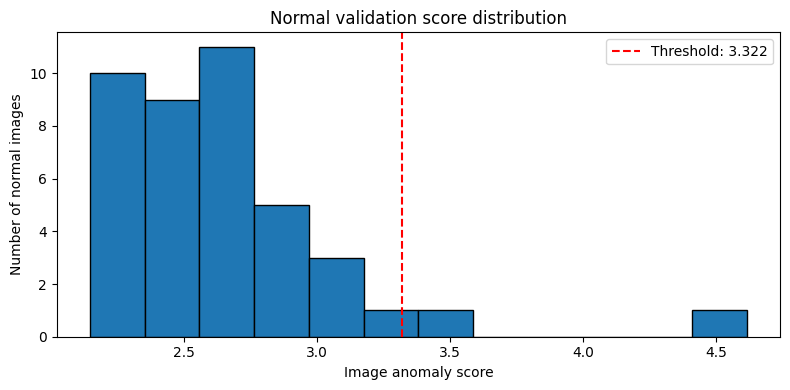

Validation results and threshold saved.


In [14]:
# wnow we plot the result
import matplotlib.pyplot as plt
import json

plt.figure(figsize=(8, 4))
plt.hist(validation_results["score"], bins=12, edgecolor="black")
plt.axvline(
    threshold,
    color="red",
    linestyle="--",
    label=f"Threshold: {threshold:.3f}",
)
plt.xlabel("Image anomaly score")
plt.ylabel("Number of normal images")
plt.title("Normal validation score distribution")
plt.legend()
plt.tight_layout()
plt.show()

validation_results.to_csv(
    artifact_dir / "random_1pct_validation_scores.csv",
    index=False,
)

with open(artifact_dir / "random_1pct_threshold.json", "w") as file:
    json.dump(
        {
            "threshold": threshold,
            "quantile": 0.95,
            "quantile_method": "higher",
            "decision_rule": "score > threshold",
            "validation_images": len(validation_results),
            "sampling": "random",
            "sampling_ratio": 0.01,
            "seed": 42,
        },
        file,
        indent=2,
    )

print("Validation results and threshold saved.")

our provisional threshold is about 3.322. Most normal validation images score below it, while one has a notably higher score near 4.5. A normal image can therefore look unusual to our small memory bank.
- earlier image scored 2.6303, so it would not be flagged under this rule.


next we evaluate the baseline on the 83 test images, keeping the threshold and sampled memory bank unchanged. Use the full-precision threshold variable, not the rounded value from the chart.


In [15]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
)

test_paths = sorted((DATA_ROOT / "test").glob("*/*.png"))

test_results = pd.DataFrame([
    {
        "image": str(path.relative_to(DATA_ROOT)),
        "category": path.parent.name,
        "is_defect": int(path.parent.name != "good"),
        "score": score_image(path),
    }
    for path in tqdm(test_paths, desc="Evaluating fixed baseline")
])

test_results["predicted_defect"] = (
    test_results["score"] > threshold
).astype(int)

y_true = test_results["is_defect"]
y_pred = test_results["predicted_defect"]

tn, fp, fn, tp = confusion_matrix(
    y_true, y_pred, labels=[0, 1]
).ravel()

print(f"Threshold: {threshold:.6f}")
print(f"Normal correctly accepted: {tn}")
print(f"Normal incorrectly flagged: {fp}")
print(f"Defects missed: {fn}")
print(f"Defects detected: {tp}")

print(
    "\n",
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["normal", "defect"],
        zero_division=0,
    ),
)

print(
    "Image-level AUROC:",
    round(roc_auc_score(y_true, test_results["score"]), 4),
)

test_results.to_csv(
    artifact_dir / "random_1pct_test_scores.csv",
    index=False,
)

Evaluating fixed baseline:   0%|          | 0/83 [00:00<?, ?it/s]

Threshold: 3.322491
Normal correctly accepted: 20
Normal incorrectly flagged: 0
Defects missed: 0
Defects detected: 63

               precision    recall  f1-score   support

      normal       1.00      1.00      1.00        20
      defect       1.00      1.00      1.00        63

    accuracy                           1.00        83
   macro avg       1.00      1.00      1.00        83
weighted avg       1.00      1.00      1.00        83

Image-level AUROC: 1.0


- False alarms and missed defects: how the system behaves at our chosen threshold.
- AUROC: how well scores rank defective images above normal ones across thresholds.
This evaluates whole-image detection. It does not yet measure how accurately the heatmap locates defects.

| Result | Value |
|---|---:|
| Normal images correctly accepted | 20/20 |
| Defective images detected | 63/63 |
| False alarms / missed defects | 0 / 0 |
| Image-level AUROC | 1.0 |
| Fixed validation threshold | 3.322491 |

For each configuration, we’ll recalibrate its threshold using the same 41 normal validation images. Different memory banks can produce different distance scales, so reusing 3.322491 for every bank would be misleading.

Our planned comparison is:
| Sampling method | Memory sizes | Seeds |
|---|---|---|
| Random sampling | 0.1%, 0.5%, 1% | 42, 43, 44 |
| Coreset selection | Same vector counts | 42, 43, 44 |

For each configuration, we’ll recalibrate its threshold using the same 41 normal validation images. Different memory banks can produce different distance scales, so reusing 3.322491 for every bank would be misleading.
Because we’ve already inspected this test set, these will be follow-up benchmark experiments. We’ll report every configuration rather than choose settings based on test performance.

In [16]:
required = [
    "DATA_ROOT",
    "artifact_dir",
    "validation_paths",
    "extractor",
    "preprocess",
    "make_patch_embeddings",
    "device",
]

missing = [name for name in required if name not in globals()]

if missing:
    raise RuntimeError(
        "The runtime is missing these objects: "
        + ", ".join(missing)
        + ". Stop here and send me this message."
    )

print("Ready to cache evaluation embeddings.")

Ready to cache evaluation embeddings.


In [17]:
import torch
from PIL import Image
from tqdm.auto import tqdm

extractor.eval()


@torch.inference_mode()
def cache_embeddings(paths, output_path):
    relative_paths = [
        str(path.relative_to(DATA_ROOT)) for path in paths
    ]

    if output_path.exists():
        print(f"Already saved: {output_path.name}")
        return

    image_embeddings = []

    for path in tqdm(paths, desc=output_path.stem):
        with Image.open(path) as image:
            batch = preprocess(
                image.convert("RGB")
            ).unsqueeze(0).to(device)

        embeddings = make_patch_embeddings(extractor(batch))
        image_embeddings.append(embeddings.cpu())

    # Preserve image boundaries:
    # [number of images, patches per image, embedding dimensions]
    stacked = torch.stack(image_embeddings)

    assert stacked.shape == (len(paths), 784, 1024)
    assert torch.isfinite(stacked).all()

    payload = {
        "paths": relative_paths,
        "embeddings": stacked,
        "backbone": "wide_resnet50_2",
        "weights": "IMAGENET1K_V1",
        "preprocessing": str(preprocess),
        "layers": ["layer2", "layer3"],
        "patch_size": 3,
        "embedding_dim": 1024,
    }

    # Mark the file complete only after saving succeeds.
    temporary_path = output_path.with_suffix(".tmp")
    torch.save(payload, temporary_path)
    temporary_path.replace(output_path)

    size_mib = stacked.numel() * stacked.element_size() / 1024**2
    print(f"Saved {tuple(stacked.shape)} — {size_mib:.1f} MiB")


test_paths = sorted((DATA_ROOT / "test").glob("*/*.png"))

cache_embeddings(
    validation_paths,
    artifact_dir / "validation_embeddings_v1.pt",
)

cache_embeddings(
    test_paths,
    artifact_dir / "test_embeddings_v1.pt",
)

Already saved: validation_embeddings_v1.pt
Already saved: test_embeddings_v1.pt


## Random-sampling experiment.
We’ll test three memory sizes with three seeds each:
- 0.1%: 131 vectors
- 0.5%: 658 vectors
- 1%: 1,317 vectors
- Seeds: 42, 43, 44

In [18]:
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_auc_score
from tqdm.auto import tqdm

validation_cache = torch.load(
    artifact_dir / "validation_embeddings_v1.pt",
    map_location="cpu",
    weights_only=True,
)

test_cache = torch.load(
    artifact_dir / "test_embeddings_v1.pt",
    map_location="cpu",
    weights_only=True,
)

validation_embeddings = validation_cache["embeddings"]
test_embeddings = test_cache["embeddings"]

# Derive labels from the saved paths, preserving their order.
from pathlib import PurePosixPath

test_labels = np.array([
    int(PurePosixPath(path).parent.name != "good")
    for path in test_cache["paths"]
])

assert len(test_embeddings) == len(test_labels) == 83
assert len(validation_embeddings) == 41

print("Evaluation features loaded.")

Evaluation features loaded.


Note: changing the seed changes which normal patterns enter the bank. Multiple seeds help distinguish a reliable result from a fortunate sample.
The 1% / seed 42 configuration should reproduce your previous baseline, allowing for small numerical differences. We’re measuring feature storage and detection quality here; runtime benchmarking will need a separate, controlled measurement.

In [19]:
# exprimenr cell
@torch.inference_mode()
def score_cached_images(cached_embeddings, bank):
    bank = bank.to(device)
    image_scores = []

    for image_embeddings in cached_embeddings:
        image_embeddings = image_embeddings.to(device)
        largest_distance = 0.0

        for chunk in image_embeddings.split(128):
            distances = torch.cdist(chunk, bank, p=2)
            nearest_squared = distances.min(dim=1).values.square()

            largest_distance = max(
                largest_distance,
                nearest_squared.max().item(),
            )

        image_scores.append(largest_distance)

    return np.array(image_scores)


ratios = [0.001, 0.005, 0.01]
seeds = [42, 43, 44]

results = []
score_records = []

for seed in tqdm(seeds, desc="Random-sampling experiment"):
    generator = torch.Generator().manual_seed(seed)
    permutation = torch.randperm(
        len(memory_bank), generator=generator
    )

    for ratio in ratios:
        count = max(1, int(len(memory_bank) * ratio))

        # Within a seed, larger banks include the smaller banks.
        indices = permutation[:count]
        bank = memory_bank[indices].contiguous()

        val_scores = score_cached_images(validation_embeddings, bank)

        run_threshold = float(
            np.quantile(val_scores, 0.95, method="higher")
        )

        test_scores = score_cached_images(test_embeddings, bank)
        predictions = (test_scores > run_threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            test_labels, predictions, labels=[0, 1]
        ).ravel()

        results.append({
            "method": "random",
            "seed": seed,
            "ratio": ratio,
            "vectors": count,
            "memory_mib": (
                bank.numel() * bank.element_size() / 1024**2
            ),
            "threshold": run_threshold,
            "validation_false_alarms": int(
                (val_scores > run_threshold).sum()
            ),
            "test_false_alarms": int(fp),
            "test_missed_defects": int(fn),
            "test_defect_recall": tp / (tp + fn),
            "test_auroc": roc_auc_score(test_labels, test_scores),
        })

        for split, cache, scores in [
            ("validation", validation_cache, val_scores),
            ("test", test_cache, test_scores),
        ]:
            for path, score in zip(cache["paths"], scores):
                score_records.append({
                    "method": "random",
                    "seed": seed,
                    "ratio": ratio,
                    "split": split,
                    "image": path,
                    "score": float(score),
                    "threshold": run_threshold,
                })

        # Save progress after each completed configuration.
        pd.DataFrame(results).to_csv(
            artifact_dir / "random_memory_comparison.csv",
            index=False,
        )
        pd.DataFrame(score_records).to_csv(
            artifact_dir / "random_memory_comparison_scores.csv",
            index=False,
        )

comparison = pd.DataFrame(results)
display(comparison.round(4))

Random-sampling experiment:   0%|          | 0/3 [00:00<?, ?it/s]

,method,seed,ratio,vectors,memory_mib,threshold,validation_false_alarms,test_false_alarms,test_missed_defects,test_defect_recall,test_auroc
0,random,42,0.001,131,0.5117,6.9298,2,1,10,0.8413,0.9405
1,random,42,0.005,658,2.5703,3.6262,2,1,0,1.0000,0.9984
2,random,42,0.010,1317,5.1445,3.3225,2,0,0,1.0000,1.0000
3,random,43,0.001,131,0.5117,6.8298,2,0,8,0.8730,0.9381
4,random,43,0.005,658,2.5703,4.3371,2,1,1,0.9841,0.9984
5,random,43,0.010,1317,5.1445,3.2518,2,1,0,1.0000,0.9976
6,random,44,0.001,131,0.5117,5.9051,2,1,4,0.9365,0.9817
7,random,44,0.005,658,2.5703,3.5444,2,2,0,1.0000,1.0000
8,random,44,0.010,1317,5.1445,3.2963,2,0,0,1.0000,1.0000


The experiment shows a clear tradeoff: the smallest random memory bank loses useful normal patterns and misses more defects. The original 1% result also reproduced successfully.
| Memory retained | Feature storage | Defects missed, across seeds | Normal images falsely flagged | AUROC range |
|---|---:|---|---|---|
| **0.1%** | 0.51 MiB | 10, 8, 4 of 63 | 1, 0, 1 of 20 | 0.9381–0.9817 |
| **0.5%** | 2.57 MiB | 0, 1, 0 of 63 | 1, 1, 2 of 20 | 0.9984–1.0000 |
| **1%** | 5.14 MiB | 0, 0, 0 of 63 | 0, 1, 0 of 20 | 0.9976–1.0000 |

Three things to learn from these results:
1. The seed matters. At 0.1%, missed defects vary from 4 to 10. A single run would hide that sensitivity to which patches were sampled.
2. Good ranking and good threshold decisions are different. At 0.5%, seed 44 has AUROC 1.0 but two false alarms. All defective images rank above normal images, yet the validation-derived threshold also flags two normal test images.
3. Two validation false alarms in every run are largely a consequence of calibration. With 41 images and our 95th-percentile rule, two scores sit above the threshold when there are no ties. This is not independent evidence that every configuration has the same real-world false-alarm rate

We’ll start with three charts answering:
1. How much memory did each configuration use?
2. How many defects did it miss?
3. How many normal images did it incorrectly flag?

## Memory-size experiment

**Question:** How much normal-feature memory can we remove before
detection quality declines?

**Pipeline:**
Normal training images → pretrained network → patch vectors →
sampled memory bank → nearest-neighbor distances → image score

**Calibration:** Set a separate threshold for each memory bank using
41 normal validation images.

**Evaluation:** Apply the fixed threshold to 83 test images:
20 normal and 63 defective.

**Experiment:** Three memory sizes × three random seeds.
Only the selected memory vectors change; the feature extractor stays fixed.

**Important:** Memory size refers to stored feature vectors, not the
entire model. All runs use the same test set.

In [20]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# The leading space matches your existing Drive folder.
artifact_dir = Path(
    "/content/drive/MyDrive/ AI-Engineering-Journey/"
    "artifacts/patchcore-bottle"
)

results_path = artifact_dir / "random_memory_comparison.csv"

if not results_path.is_file():
    raise FileNotFoundError(
        "Results CSV not found. Mount Drive and check the path:\n"
        f"{results_path}"
    )

results = pd.read_csv(results_path)
results = results[results["method"] == "random"].copy()

assert len(results) == 9, "Expected nine experiment results."
assert not results.duplicated(["seed", "ratio"]).any()

ratios = sorted(results["ratio"].unique())
seeds = sorted(results["seed"].unique())

figures_dir = artifact_dir / "figures"
figures_dir.mkdir(exist_ok=True)

print("Loaded nine runs. Ready to plot.")

Loaded nine runs. Ready to plot.


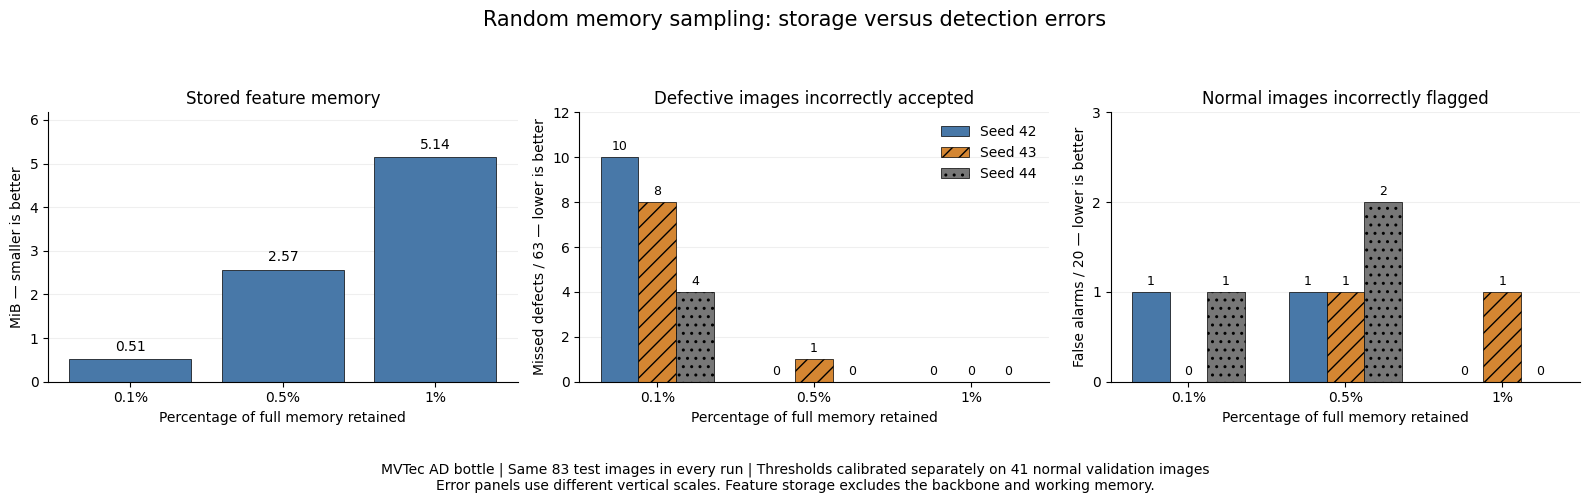

Saved: /content/drive/MyDrive/ AI-Engineering-Journey/artifacts/patchcore-bottle/figures/random_memory_tradeoff.png


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

x = np.arange(len(ratios))
labels = [f"{ratio * 100:g}%" for ratio in ratios]

# Chart 1: feature storage, identical across seeds at each ratio.
storage = (
    results.groupby("ratio")["memory_mib"]
    .first()
    .reindex(ratios)
)

bars = axes[0].bar(
    x, storage,
    color="#4878A8",
    edgecolor="black",
    linewidth=0.5,
)

axes[0].bar_label(bars, fmt="%.2f", padding=4)
axes[0].set_title("Stored feature memory")
axes[0].set_ylabel("MiB — smaller is better")
axes[0].set_ylim(0, storage.max() * 1.2)

# Charts 2 and 3: preserve the individual seed results.
colors = ["#4878A8", "#D48632", "#777777"]
hatches = ["", "//", ".."]
width = 0.24

for position, seed in enumerate(seeds):
    run = (
        results[results["seed"] == seed]
        .set_index("ratio")
        .reindex(ratios)
    )

    offset = (position - 1) * width

    for ax, metric in [
        (axes[1], "test_missed_defects"),
        (axes[2], "test_false_alarms"),
    ]:
        bars = ax.bar(
            x + offset,
            run[metric],
            width=width,
            label=f"Seed {seed}",
            color=colors[position],
            hatch=hatches[position],
            edgecolor="black",
            linewidth=0.5,
        )

        ax.bar_label(bars, fmt="%.0f", padding=3, fontsize=9)

axes[1].set_title("Defective images incorrectly accepted")
axes[1].set_ylabel("Missed defects / 63 — lower is better")
axes[1].set_ylim(0, max(1, results["test_missed_defects"].max()) + 2)

axes[2].set_title("Normal images incorrectly flagged")
axes[2].set_ylabel("False alarms / 20 — lower is better")
axes[2].set_ylim(0, max(1, results["test_false_alarms"].max()) + 1)

for ax in axes:
    ax.set_xticks(x, labels)
    ax.set_xlabel("Percentage of full memory retained")
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_axisbelow(True)
    ax.grid(axis="y", alpha=0.2)

for ax in axes[1:]:
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

axes[1].legend(frameon=False)

fig.suptitle(
    "Random memory sampling: storage versus detection errors",
    fontsize=15,
)

fig.text(
    0.5, 0.02,
    "MVTec AD bottle | Same 83 test images in every run | "
    "Thresholds calibrated separately on 41 normal validation images\n"
    "Error panels use different vertical scales. "
    "Feature storage excludes the backbone and working memory.",
    ha="center",
    fontsize=10,
)

fig.tight_layout(rect=[0, 0.12, 1, 0.92])

output_path = figures_dir / "random_memory_tradeoff.png"
fig.savefig(output_path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", output_path)

- Left: increasing the memory budget costs more storage.
- Middle: the smallest bank misses defects across every seed; the 1% bank misses none in these runs.
- Right: false alarms still vary. Detecting every defect does not guarantee accepting every normal image.
- The three bars at each memory size show sampling variability, not results from different datasets.
These charts preserve all nine runs instead of hiding variation behind averages.
Run the cells and send me the figure. Next, we can add a score-distribution plot with the threshold—that will make the difference between AUROC and threshold-based errors much easier to see.


14:42

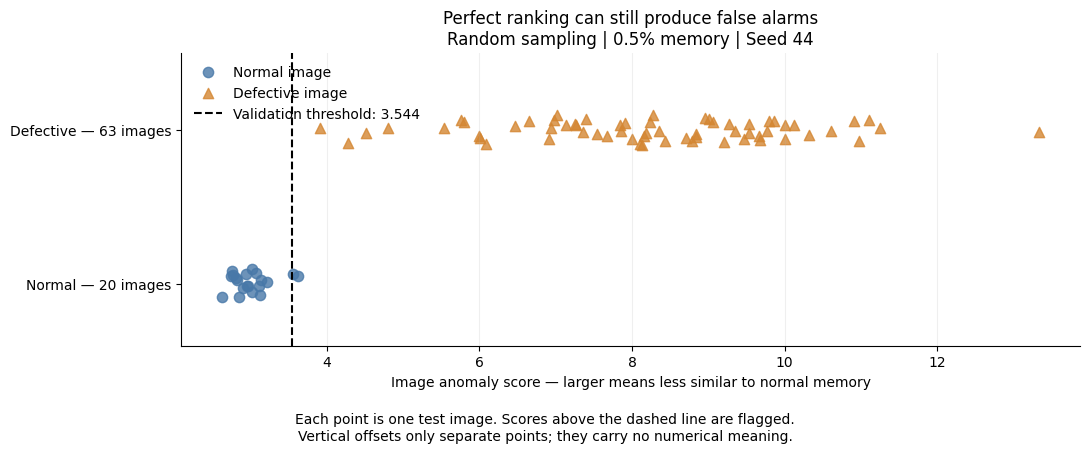

Highest normal score: 3.6238
Lowest defect score:  3.9085
Threshold:            3.5444
Normal images above threshold: 2


In [22]:
from pathlib import PurePosixPath
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

scores = pd.read_csv(
    artifact_dir / "random_memory_comparison_scores.csv"
)

selected = scores[
    (scores["method"] == "random")
    & (scores["seed"] == 44)
    & np.isclose(scores["ratio"], 0.005)
    & (scores["split"] == "test")
].copy()

assert len(selected) == 83, "Expected 83 test images."

selected["is_defect"] = selected["image"].apply(
    lambda path: PurePosixPath(path).parent.name != "good"
)

assert selected["threshold"].nunique() == 1
selected_threshold = selected["threshold"].iloc[0]

normal_scores = selected.loc[~selected["is_defect"], "score"]
defect_scores = selected.loc[selected["is_defect"], "score"]

# Small vertical offsets separate overlapping points.
rng = np.random.default_rng(42)

fig, ax = plt.subplots(figsize=(11, 4.5))

ax.scatter(
    normal_scores,
    rng.uniform(-0.10, 0.10, len(normal_scores)),
    color="#4878A8",
    marker="o",
    s=55,
    alpha=0.8,
    label="Normal image",
)

ax.scatter(
    defect_scores,
    1 + rng.uniform(-0.10, 0.10, len(defect_scores)),
    color="#D48632",
    marker="^",
    s=55,
    alpha=0.8,
    label="Defective image",
)

ax.axvline(
    selected_threshold,
    color="black",
    linestyle="--",
    label=f"Validation threshold: {selected_threshold:.3f}",
)

ax.set_yticks([0, 1], ["Normal — 20 images", "Defective — 63 images"])
ax.set_ylim(-0.4, 1.5)
ax.set_xlabel("Image anomaly score — larger means less similar to normal memory")
ax.set_title(
    "Perfect ranking can still produce false alarms\n"
    "Random sampling | 0.5% memory | Seed 44"
)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.2)
ax.legend(loc="upper left", frameon=False)

fig.text(
    0.5, 0.01,
    "Each point is one test image. Scores above the dashed line are flagged.\n"
    "Vertical offsets only separate points; they carry no numerical meaning.",
    ha="center",
    fontsize=10,
)

fig.tight_layout(rect=[0, 0.09, 1, 1])
fig.savefig(
    figures_dir / "ranking_vs_threshold_seed44_0p5pct.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

print(f"Highest normal score: {normal_scores.max():.4f}")
print(f"Lowest defect score:  {defect_scores.min():.4f}")
print(f"Threshold:            {selected_threshold:.4f}")
print(f"Normal images above threshold: {(normal_scores > selected_threshold).sum()}")

implement coreset selection and compare it with random sampling at the same memory sizes.Random sampling may miss unusual but valid normal patterns. A coreset tries to keep vectors that cover different parts of the normal feature space.The selection process is:


- Start with a selected vector.
- Measure each remaining vector’s distance to its nearest selected vector.
- Select the vector with the largest nearest distance.
Update distances and repeat.

This is called greedy farthest-first selection. It uses training features only.
For our 131,712 vectors, we’ll first project the 1,024 features down to 128 dimensions to make selection cheaper. We will still use the original 1,024-dimensional vectors for anomaly scoring.
Our implementation will be a transparent approximation, rather than an exact reproduction of the official sampler.

In [23]:
import torch

required = ["memory_bank", "device", "artifact_dir"]
missing = [name for name in required if name not in globals()]

if missing:
    raise RuntimeError(
        "Missing variables: " + ", ".join(missing)
    )


@torch.inference_mode()
def project_for_selection(memory_bank, seed, output_dim=128):
    """Reduce dimensions for selection, preserving the original bank."""
    generator = torch.Generator(device="cpu").manual_seed(seed)

    projection = torch.randn(
        memory_bank.shape[1],
        output_dim,
        generator=generator,
        dtype=torch.float32,
    ) / (output_dim ** 0.5)

    projection = projection.to(device)
    projected_chunks = []

    for chunk in memory_bank.split(4096):
        projected_chunks.append(
            chunk.to(device=device, dtype=torch.float32) @ projection
        )

    return torch.cat(projected_chunks, dim=0)


projected_memory = project_for_selection(memory_bank, seed=42)

assert projected_memory.shape == (len(memory_bank), 128)
assert torch.isfinite(projected_memory).all()

print("Original bank:", tuple(memory_bank.shape))
print("Selection features:", tuple(projected_memory.shape))

Original bank: (131712, 1024)
Selection features: (131712, 128)


What changed? The number of vectors stays the same. Only their temporary descriptions become shorter for selection. Projection approximately preserves distances; it can distort them, so this is an efficiency tradeoff.